Put this file in the same parent folder as train_images folder



**Note:** Ensure that your environment has these libraries installed (e.g., using `pip install opencv-python numpy pandas matplotlib seaborn tensorflow scikit-learn optuna`). Also, make sure your project directory contains the required files (such as `meta_train.csv`) and folders (like `train_images`).

In [ ]:
# %pip install opencv-python pandas numpy matplotlib seaborn tensorflow scikit-learn optuna optuna-integration

# 1. Essential Libraries and Setup

This cell imports all the required libraries for file operations, image processing, machine learning (TensorFlow/Keras), data manipulation (Pandas and NumPy), visualization (Matplotlib and Seaborn), and hyperparameter tuning (Optuna). It also sets up the configuration parameters for the project.

In [2]:
# === Essential Libraries ===
import os                   # Operating system utilities (file path handling, directory operations)
import csv                  # CSV file reading and writing
import gc                   # Garbage collection control (manual memory cleanup)
import cv2                  # OpenCV library for image processing
import numpy as np          # Numerical operations with arrays
import pandas as pd         # Data manipulation and analysis (DataFrames)
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns       # Statistical data visualization (built on matplotlib)
from shutil import rmtree   # High-level file operations, here used to remove directories

# === TensorFlow and Keras ===
import tensorflow as tf     # Deep learning framework core
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, backend as K  # Neural network building blocks and utilities
from tensorflow.keras.preprocessing.image import ImageDataGenerator    # For image augmentation and preprocessing
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Callbacks for training control and model saving

# === Scikit-learn Utilities ===
from sklearn.model_selection import train_test_split         # Split datasets into training and validation sets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
from sklearn.utils import class_weight                        # Compute class weights for imbalance handling

# === Optuna for Hyperparameter Tuning ===
import optuna                                               # Framework for automated hyperparameter optimization
from optuna.samplers import TPESampler                      # Tree-structured Parzen Estimator sampler for efficient search
from optuna.pruners import MedianPruner                     # Median pruner for early stopping of bad trials
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau # Callbacks for training control
from optuna.integration import TFKerasPruningCallback  # Optuna callback integration with Keras for pruning

# === Configuration Dictionary ===
CONFIG = {
    'SEED': 42,                          # Random seed for reproducibility
    'INPUT_SIZE': (224, 224),            # Image size for model input (height, width)
    'BATCH_SIZE': 32,                    # Number of samples per training batch
    'EPOCHS': 50,                       # Maximum number of training epochs
    'EARLY_STOP_PATIENCE': 10,           # Early stopping patience epochs without improvement
    'CSV_PATH': 'meta_train_with_aug_combined.csv',  # Path to metadata CSV with augmented images info
    'IMAGE_DIR': 'clean_train_images',    # Directory containing cleaned and processed images
    'MODEL_DIR': 'saved_models_classification', # Directory to save trained models and results
}

# === Setup ===
os.makedirs(CONFIG['MODEL_DIR'], exist_ok=True)  # Create the model directory if it doesn't exist
tf.random.set_seed(CONFIG['SEED'])               # Set TensorFlow random seed for reproducibility
pd.options.mode.chained_assignment = None        # Disable chained assignment warnings in pandas


c:\Users\Hoang Tran\anaconda3\envs\tf2.10-py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Data Cleaning and Image Validation

In this section, we set up paths for the original metadata and images, then proceed to clean and validate the dataset. For each image referenced in `meta_train.csv`, we confirm its existence, check for corruption, verify its resolution, and then save the validated image in the `clean_train_images` folder.

In [4]:
# === Data Cleaning ===

# Define paths for the metadata CSV and image folders
meta_path = "meta_train.csv"            # Path to CSV file containing image metadata
train_dir = "train_images"              # Folder containing the original raw images
clean_dir = CONFIG['IMAGE_DIR']         # Folder to save cleaned and validated images (from config)

# Recreate the clean_dir folder to start fresh
if os.path.exists(clean_dir):
    rmtree(clean_dir)                   # Remove existing clean_dir folder and all its contents
os.makedirs(clean_dir)                   # Create a new empty clean_dir folder

# Load the metadata CSV into a pandas DataFrame
meta_df = pd.read_csv(meta_path)
print("Metadata loaded. Number of entries:", len(meta_df))  # Print number of rows loaded

# Define expected image resolution constraints
EXPECTED_WIDTH_RANGE = (480, 640)       # Acceptable width range for images
EXPECTED_HEIGHT = 640                   # Expected fixed height for images

# Initialize a list to record any issues found during cleaning
issues = []

# Iterate over each row in the metadata DataFrame
for idx, row in meta_df.iterrows():
    image_id = row['image_id']           # Image filename (including extension, e.g., "img001.jpg")
    label = row['label']                 # Class label or folder name for the image
    image_path = os.path.join(train_dir, label, image_id)  # Construct full path to the original image

    # Check if the image file exists
    if not os.path.exists(image_path):
        issues.append(f"Missing image: {image_path}")   # Log missing file
        continue                                        # Skip to next image

    # Read the image using OpenCV
    img = cv2.imread(image_path)
    if img is None:
        issues.append(f"Corrupted image: {image_path}")  # Log unreadable or corrupted image
        continue                                        # Skip to next image

    # Get the height and width of the image
    height, width = img.shape[:2]

    # Check if the image resolution is within the expected range
    if not (EXPECTED_WIDTH_RANGE[0] <= width <= EXPECTED_WIDTH_RANGE[1] and height == EXPECTED_HEIGHT):
        issues.append(f"Unexpected resolution ({width}x{height}) for image: {image_path}")
        # Optional: you could resize the image here if desired, e.g.:
        # img = cv2.resize(img, (EXPECTED_WIDTH_RANGE[0], EXPECTED_HEIGHT))

    # Define destination folder path for the cleaned image, organized by label
    dest_folder = os.path.join(clean_dir, label)
    os.makedirs(dest_folder, exist_ok=True)   # Create label folder if it doesn't exist

    # Define full destination path for the cleaned image
    dest_path = os.path.join(dest_folder, image_id)

    # Save the (possibly resized) image to the cleaned images folder
    cv2.imwrite(dest_path, img)

# After processing all images, print any issues encountered
print("Data cleaning issues found:")
for issue in issues:
    print(issue)


Metadata loaded. Number of entries: 10407
Data cleaning issues found:
Unexpected resolution (640x480) for image: train_images\bacterial_leaf_blight\100622.jpg
Unexpected resolution (640x480) for image: train_images\bacterial_leaf_blight\103734.jpg
Unexpected resolution (640x480) for image: train_images\brown_spot\103050.jpg
Unexpected resolution (640x480) for image: train_images\brown_spot\103343.jpg


# 3. Merging Metadata with Cleaned Files and Splitting Data

After cleaning the image files, we build a DataFrame from the cleaned images and merge it with the original metadata. We then perform a stratified split to create training and validation datasets.

In [5]:
# === Load processed metadata and compute number of classes ===

# Read the combined metadata CSV file containing info about cleaned and augmented images
train_meta = pd.read_csv(CONFIG['CSV_PATH'])

# Calculate the number of unique classes/labels in the dataset
num_classes = len(train_meta['label'].unique())

# Create a list to store metadata info derived from the cleaned image files on disk
cleaned_files = []

# Loop through each label folder in the cleaned image directory
for label in os.listdir(clean_dir):
    label_folder = os.path.join(clean_dir, label)   # Full path to label folder
    # Loop through all files inside the label folder
    for file in os.listdir(label_folder):
        # Append a dictionary with image filename and corresponding label folder
        cleaned_files.append({"image_id": file, "label_from_folder": label})

# Convert the list of cleaned files into a DataFrame for easier manipulation
cleaned_files_df = pd.DataFrame(cleaned_files)

# Print a sample of the cleaned files metadata to verify correctness
print("Cleaned files sample:")
print(cleaned_files_df.head())

# Merge the original metadata DataFrame (meta_df) with the cleaned files DataFrame on 'image_id'
# This ensures we only keep metadata for images that are actually cleaned and available
merged_df = pd.merge(meta_df, cleaned_files_df, on="image_id", how="inner")

# Print a sample of the merged DataFrame to verify the merge
print("Merged dataset summary:")
print(merged_df.head())

# Split the original metadata DataFrame (meta_df) into training and validation sets
# Use stratified splitting to maintain the same label distribution in both sets
train_meta, val_meta = train_test_split(
    meta_df,                 # Input data to split
    test_size=0.2,           # 20% for validation
    random_state=42,         # Seed for reproducibility
    stratify=meta_df['label']  # Stratify by label for balanced splits
)

# Print the size of training and validation datasets
print("Training samples:", len(train_meta), "Validation samples:", len(val_meta))


Cleaned files sample:
     image_id      label_from_folder
0  100023.jpg  bacterial_leaf_blight
1  100049.jpg  bacterial_leaf_blight
2  100126.jpg  bacterial_leaf_blight
3  100133.jpg  bacterial_leaf_blight
4  100148.jpg  bacterial_leaf_blight
Merged dataset summary:
     image_id                  label variety  age      label_from_folder
0  100330.jpg  bacterial_leaf_blight   ADT45   45  bacterial_leaf_blight
1  100365.jpg  bacterial_leaf_blight   ADT45   45  bacterial_leaf_blight
2  100382.jpg  bacterial_leaf_blight   ADT45   45  bacterial_leaf_blight
3  100632.jpg  bacterial_leaf_blight   ADT45   45  bacterial_leaf_blight
4  101918.jpg  bacterial_leaf_blight   ADT45   45  bacterial_leaf_blight
Training samples: 8325 Validation samples: 2082


# 4. Augmentation Pipeline

We define an image augmentation pipeline using Keras’ `ImageDataGenerator` to increase dataset variability, especially beneficial for underrepresented classes.

In [6]:

# Define an image augmentation pipeline using Keras' ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,         # Randomly rotate images in the range of ±20 degrees
    width_shift_range=0.1,     # Randomly shift images horizontally by up to 10% of the width
    height_shift_range=0.1,    # Randomly shift images vertically by up to 10% of the height
    shear_range=0.1,           # Apply random shear transformations up to 10%
    zoom_range=0.1,            # Randomly zoom in/out up to 10%
    horizontal_flip=True,      # Randomly flip images horizontally
    fill_mode='reflect'        # Fill in newly created pixels after transformations by reflecting the image border pixels
)


# 5. Augmenting Training Images for a Specific Class

This function augments images for a specified class. It filters training images, generates augmented samples, and saves them in a subfolder under the class folder.

In [7]:
# ====================================================================
# Augment Only Training Images for a Given Class
# ====================================================================

def augment_class_images(class_name, source_dir, train_meta, num_aug=3):
    """
    Augment images for a specified class, but only for images that are in the training metadata.
    
    :param class_name: The name of the class to augment, e.g., "bacterial_leaf_blight"
    :param source_dir: Root directory containing class subfolders (usually the cleaned images directory)
    :param train_meta: DataFrame containing metadata only for training images
    :param num_aug: Number of augmented images to generate per original image
    """
    # Filter training metadata to include only rows for the specified class
    class_train_meta = train_meta[train_meta['label'] == class_name]
    # Create a set of image IDs for quick membership checks to ensure only training images are augmented
    train_image_ids = set(class_train_meta['image_id'])

    # Define source directory path for this class
    class_source = os.path.join(source_dir, class_name)
    # Define the destination directory for augmented images within this class folder
    augmented_dir = os.path.join(class_source, "augmented")
    # Create augmented directory if it does not exist
    if not os.path.exists(augmented_dir):
        os.makedirs(augmented_dir)

    # Iterate over all files in the class source directory
    for image_file in os.listdir(class_source):
        # Skip the 'augmented' folder itself or any file not in training image IDs
        if image_file == "augmented" or image_file not in train_image_ids:
            continue

        # Full path to the original image file
        img_path = os.path.join(class_source, image_file)
        # Read image using OpenCV (reads in BGR format)
        img = cv2.imread(img_path)
        # Skip if image loading failed
        if img is None:
            continue

        # Convert image from BGR to RGB for compatibility with Keras ImageDataGenerator
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Reshape image to (1, height, width, channels) to create a batch of size 1 for the generator
        img_array = img_rgb.reshape((1,) + img_rgb.shape)
        # Create an augmentation iterator from the ImageDataGenerator pipeline
        aug_iter = datagen.flow(img_array, batch_size=1, seed=42)

        # Generate and save the specified number of augmented images per original image
        for i in range(num_aug):
            # Generate next augmented image batch, take the image at index 0
            aug_image = next(aug_iter)[0]
            # Convert the image array to uint8 (0-255) type for saving
            aug_image = aug_image.astype('uint8')
            # Create a new filename for the augmented image
            save_name = f"{os.path.splitext(image_file)[0]}_aug_{i}.jpg"
            # Full path for saving augmented image
            save_path = os.path.join(augmented_dir, save_name)
            # Convert augmented image back to BGR for OpenCV saving
            aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
            # Save the augmented image to disk
            cv2.imwrite(save_path, aug_image_bgr)

    # Print a message indicating augmentation for this class is complete
    print(f"Augmentation complete for class: {class_name}")


# 6. Resolution Verification of Cleaned Images

This function scans through the cleaned images folder, verifying that each image matches the expected resolution (480x640). It returns the total number of images checked and a list of images that do not meet the resolution criteria.

In [ ]:
def check_all_images_resolution(root_dir, expected_width=480, expected_height=640):
    """
    Walk through all subdirectories of root_dir and check each image's resolution.
    Ensures each image has exactly the expected width and height.

    :param root_dir: Root directory to scan (e.g., "clean_train_images")
    :param expected_width: Expected image width (pixels)
    :param expected_height: Expected image height (pixels)
    :return: total_images (int), incorrect_images (list of tuples)
             incorrect_images contains tuples of (image_path, width, height)
             or (image_path, "Image could not be loaded") if unreadable.
    """
    incorrect_images = []  # List to store info on images not matching expected resolution
    total_images = 0       # Counter for total images scanned

    # Walk through all folders and files recursively starting from root_dir
    for subdir, dirs, files in os.walk(root_dir):
        for file in files:
            # Filter files for common image formats (case-insensitive)
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                total_images += 1
                image_path = os.path.join(subdir, file)  # Full path to image
                img = cv2.imread(image_path)             # Read image using OpenCV

                if img is None:
                    # Could not load image, mark it as an issue
                    incorrect_images.append((image_path, "Image could not be loaded"))
                    continue

                # OpenCV shape is (height, width, channels)
                h, w = img.shape[:2]

                # Check if width and height match the expected dimensions
                if w != expected_width or h != expected_height:
                    incorrect_images.append((image_path, w, h))

    return total_images, incorrect_images

# === Usage example ===
# Set your cleaned images folder path
root_directory = "clean_train_images"

# Run the resolution check function
total, wrong_images = check_all_images_resolution(root_directory, expected_width=480, expected_height=640)

print(f"Total images checked: {total}")
if wrong_images:
    print("The following images do not meet the expected resolution of 480x640:")
    for item in wrong_images:
        print(item)
else:
    print("All images meet the expected resolution of 480x640.")


Total images checked: 10407
The following images do not meet the expected resolution of 480x640:
('clean_train_images\\bacterial_leaf_blight\\100622.jpg', 640, 480)
('clean_train_images\\bacterial_leaf_blight\\103734.jpg', 640, 480)
('clean_train_images\\brown_spot\\103050.jpg', 640, 480)
('clean_train_images\\brown_spot\\103343.jpg', 640, 480)


**Explanation**: This section verifies that all images in the `clean_train_images` folder conform to the expected resolution. It prints the total number of images checked and lists any images that deviate from the expected dimensions.

# 7. Correcting Image Orientation

Before performing any further augmentation or analysis, it is important to ensure that all images have the correct orientation. The following function checks all image files under a given root directory. If an image has dimensions 640x480 (instead of the expected 480x640), it rotates the image 90 degrees clockwise to correct its orientation.

**Note:** Ensure that your `clean_train_images` folder is present in your working directory. Running this code will update the images in place.

In [ ]:
def correct_image_orientation(root_dir, expected_width=480, expected_height=640):
    """
    Checks all image files in root_dir and rotates those that have dimensions 640x480
    to convert them into the expected orientation 480x640.

    :param root_dir: Directory to scan for images (e.g., "clean_train_images")
    :param expected_width: Expected width after correction (default 480)
    :param expected_height: Expected height after correction (default 640)
    """
    corrected = 0  # Counter for how many images were corrected

    # Walk through all folders and files recursively
    for subdir, dirs, files in os.walk(root_dir):
        for file in files:
            # Consider common image extensions
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(subdir, file)
                img = cv2.imread(image_path)  # Load image with OpenCV

                if img is None:
                    # Skip if image cannot be loaded
                    continue

                h, w = img.shape[:2]  # Get current height and width

                # Check if image is in the wrong orientation: width == expected_height and height == expected_width
                if w == expected_height and h == expected_width:
                    # Rotate 90 degrees clockwise to fix orientation
                    img_rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

                    # Verify new dimensions after rotation
                    new_h, new_w = img_rotated.shape[:2]

                    if new_w == expected_width and new_h == expected_height:
                        # Save rotated image back to disk
                        cv2.imwrite(image_path, img_rotated)
                        corrected += 1
                        print(f"Corrected orientation for {image_path} (now {new_w}x{new_h})")

    print(f"Total images corrected: {corrected}")

# === Usage ===
root_directory = "clean_train_images"
correct_image_orientation(root_directory, expected_width=480, expected_height=640)


Corrected orientation for clean_train_images\bacterial_leaf_blight\100622.jpg (now 480x640)
Corrected orientation for clean_train_images\bacterial_leaf_blight\103734.jpg (now 480x640)
Corrected orientation for clean_train_images\brown_spot\103050.jpg (now 480x640)
Corrected orientation for clean_train_images\brown_spot\103343.jpg (now 480x640)
Total images corrected: 4


# 8. Augmenting Images for Specific Classes

For classes that require augmentation (to help balance the dataset or increase robustness), we use a predefined augmentation function. Here, we run augmentation for the "`bacterial_leaf_blight`" class. This function, defined previously as `augment_class_images`, uses our augmentation pipeline to create extra images only for training images.

**Warning**: Make sure that the metadata (`train_meta`) and the cleaned images directory (`clean_dir`) are correctly set and that the training split contains images for this class.

In [41]:
# Run augmentation for the "bacterial_leaf_blight" class using only training images.
augment_class_images("bacterial_leaf_blight", clean_dir, train_meta, num_aug=3)

Augmentation complete for class: bacterial_leaf_blight


# 9. Updating Metadata for Augmented Images – Bacterial Leaf Blight

The following code block updates the metadata to include augmented images for the "`bacterial_leaf_blight`" class. For each original image, it creates metadata entries for the additional augmented images (here, creating 3 extra copies per image). The new metadata is then saved to a CSV file.

**Explanation**: The process involves filtering the training metadata for the specific class, generating new image IDs for augmented copies (which are stored under an "augmented" subfolder), appending these rows, and saving the combined data.

In [ ]:
# ====================================================================
#  Update Metadata for Augmented Images (Training Only)
# ====================================================================

# Filter out only the "bacterial_leaf_blight" entries from the training metadata.
meta_blab = train_meta[train_meta["label"] == "bacterial_leaf_blight"]

# Number of augmented copies to create per original image (same as used above)
num_aug = 3

# Container for new metadata rows for augmented images.
augmented_meta_rows = []

# For every original "bacterial_leaf_blight" image in the training set, create new rows.
for _, row in meta_blab.iterrows():
    original_id = row["image_id"]
    for i in range(num_aug):
        # Construct the new image_id. The images are stored in the "augmented" subfolder.
        new_id = f"augmented/{os.path.splitext(original_id)[0]}_aug_{i}.jpg"
        new_row = row.copy()  # Copy the row so that metadata is preserved.
        new_row["image_id"] = new_id  # Update image_id to the augmented file's relative path.
        augmented_meta_rows.append(new_row)

# Create a DataFrame from the augmented metadata rows.
aug_meta_df = pd.DataFrame(augmented_meta_rows)

# Combine the original training metadata for "bacterial_leaf_blight" with the augmented metadata.
combined_blab_df = pd.concat([meta_blab, aug_meta_df], ignore_index=True)

# Optionally, inspect the combined DataFrame.
print(combined_blab_df.head())
print("Total number of bacterial_leaf_blight images (original + augmented):", len(combined_blab_df))

# Save the combined DataFrame to a new CSV file.
combined_blab_df.to_csv("meta_train_with_aug_bacterial_leaf_blight.csv", index=False)
print("CSV file saved as 'meta_train_with_aug_bacterial_leaf_blight.csv'")

     image_id                  label variety  age
0  100234.jpg  bacterial_leaf_blight   ADT45   60
1  102639.jpg  bacterial_leaf_blight   ADT45   68
2  103048.jpg  bacterial_leaf_blight   ADT45   72
3  104430.jpg  bacterial_leaf_blight   ADT45   68
4  103276.jpg  bacterial_leaf_blight   ADT45   72
Total number of bacterial_leaf_blight images (original + augmented): 1532
CSV file saved as 'meta_train_with_aug_bacterial_leaf_blight.csv'


# 10. Updating Metadata for Other Classes (Tungro, Bacterial Leaf Streak, etc.)

Similar procedures are used to augment and update metadata for other classes (e.g., Tungro, Bacterial Leaf Streak, Bacterial Panicle Blight, Brown Spot, Downy Mildew). Each block sets the number of augmentations per class and saves the corresponding augmented metadata CSV.

Note: Adjust `num_aug` for each class as required. The code below for each class is similar to that used for "bacterial_leaf_blight".

In [43]:
# -------- A. Tungro (num_aug = 1) --------
augment_class_images("tungro", clean_dir, train_meta, num_aug=1)

Augmentation complete for class: tungro


In [ ]:
# Select all rows where label is "tungro" from the training metadata
meta_tungro = train_meta[train_meta["label"] == "tungro"]

augmented_meta_rows = []  # List to store new rows for augmented images
num_aug = 1  # Number of augmented images to create per original image

# Loop through each tungro image metadata row
for _, row in meta_tungro.iterrows():
    original_id = row["image_id"]  # Get the original image filename
    
    # For each augmentation iteration, create new metadata entries
    for i in range(num_aug):
        # Construct new image_id with "augmented/" folder prefix and augmentation suffix
        new_id = f"augmented/{os.path.splitext(original_id)[0]}_aug_{i}.jpg"
        
        new_row = row.copy()  # Copy the original row to modify
        new_row["image_id"] = new_id  # Update image_id to the augmented image filename
        
        augmented_meta_rows.append(new_row)  # Add the new metadata row to the list

# Create a DataFrame from all augmented metadata rows
aug_meta_df = pd.DataFrame(augmented_meta_rows)

# Combine the original tungro metadata with the augmented metadata
combined_tungro_df = pd.concat([meta_tungro, aug_meta_df], ignore_index=True)

# Save the combined DataFrame to a new CSV file
combined_tungro_df.to_csv("meta_train_with_aug_tungro.csv", index=False)

print("CSV file saved as 'meta_train_with_aug_tungro.csv'")


CSV file saved as 'meta_train_with_aug_tungro.csv'


In [45]:
# -------- B. Bacterial Leaf Streak (num_aug = 4) --------
augment_class_images("bacterial_leaf_streak", clean_dir, train_meta, num_aug=4)

Augmentation complete for class: bacterial_leaf_streak


In [ ]:
# Select all rows where label is "bacterial_leaf_streak" from the training metadata
meta_streak = train_meta[train_meta["label"] == "bacterial_leaf_streak"]

augmented_meta_rows = []  # List to hold metadata rows for augmented images
num_aug = 4  # Number of augmented images to generate per original image

# Loop over each metadata row of the bacterial_leaf_streak class
for _, row in meta_streak.iterrows():
    original_id = row["image_id"]  # Original image filename
    
    # For each augmentation, create a new metadata entry
    for i in range(num_aug):
        # Construct new image filename with "augmented/" folder and augmentation suffix
        new_id = f"augmented/{os.path.splitext(original_id)[0]}_aug_{i}.jpg"
        
        new_row = row.copy()  # Copy the current metadata row
        new_row["image_id"] = new_id  # Update image_id to point to the augmented image
        
        augmented_meta_rows.append(new_row)  # Add the new row to the list

# Create a DataFrame for all augmented metadata rows
aug_meta_df = pd.DataFrame(augmented_meta_rows)

# Combine original metadata with the augmented metadata
combined_streak_df = pd.concat([meta_streak, aug_meta_df], ignore_index=True)

# Save the combined DataFrame to a CSV file
combined_streak_df.to_csv("meta_train_with_aug_bacterial_leaf_streak.csv", index=False)

print("CSV file saved as 'meta_train_with_aug_bacterial_leaf_streak.csv'")


CSV file saved as 'meta_train_with_aug_bacterial_leaf_streak.csv'


In [47]:
# -------- C. Bacterial Panicle Blight (num_aug = 5) --------
augment_class_images("bacterial_panicle_blight", clean_dir, train_meta, num_aug=5)

Augmentation complete for class: bacterial_panicle_blight


In [ ]:
# Select all rows where the label is "bacterial_panicle_blight" from the training metadata
meta_panicle = train_meta[train_meta["label"] == "bacterial_panicle_blight"]

augmented_meta_rows = []  # List to store metadata entries for augmented images
num_aug = 5  # Number of augmented images to generate per original image

# Iterate over each metadata entry of the "bacterial_panicle_blight" class
for _, row in meta_panicle.iterrows():
    original_id = row["image_id"]  # Original image filename
    
    # For each augmentation, create a new metadata row
    for i in range(num_aug):
        # Construct new image filename with "augmented/" folder and augmentation index
        new_id = f"augmented/{os.path.splitext(original_id)[0]}_aug_{i}.jpg"
        
        new_row = row.copy()  # Create a copy of the current metadata row
        new_row["image_id"] = new_id  # Update the image_id to point to the augmented image
        
        augmented_meta_rows.append(new_row)  # Add the new augmented row to the list

# Convert the list of augmented metadata rows into a DataFrame
aug_meta_df = pd.DataFrame(augmented_meta_rows)

# Combine original metadata and augmented metadata into a single DataFrame
combined_panicle_df = pd.concat([meta_panicle, aug_meta_df], ignore_index=True)

# Save the combined DataFrame to a CSV file for training use
combined_panicle_df.to_csv("meta_train_with_aug_bacterial_panicle_blight.csv", index=False)

print("CSV file saved as 'meta_train_with_aug_bacterial_panicle_blight.csv'")


CSV file saved as 'meta_train_with_aug_bacterial_panicle_blight.csv'


In [49]:
# -------- D. Brown Spot (num_aug = 1) --------
augment_class_images("brown_spot", clean_dir, train_meta, num_aug=1)

Augmentation complete for class: brown_spot


In [ ]:
# Select rows where the label is "brown_spot" from the training metadata
meta_brown_spot = train_meta[train_meta["label"] == "brown_spot"]

augmented_meta_rows = []  # List to hold new metadata rows for augmented images
num_aug = 1  # Number of augmented images to create per original image

# Iterate through each original image metadata row in the "brown_spot" class
for _, row in meta_brown_spot.iterrows():
    original_id = row["image_id"]  # Original image filename
    
    # Generate augmented image metadata entries
    for i in range(num_aug):
        # Construct new augmented image filename, under "augmented" folder with index suffix
        new_id = f"augmented/{os.path.splitext(original_id)[0]}_aug_{i}.jpg"
        
        new_row = row.copy()  # Copy the metadata row to modify it safely
        new_row["image_id"] = new_id  # Update image_id to augmented image filename
        
        augmented_meta_rows.append(new_row)  # Add new augmented metadata to the list

# Convert augmented metadata rows list into a DataFrame
aug_meta_df = pd.DataFrame(augmented_meta_rows)

# Concatenate original and augmented metadata DataFrames, ignoring original index
combined_brown_spot_df = pd.concat([meta_brown_spot, aug_meta_df], ignore_index=True)

# Save the combined metadata to a CSV file for training
combined_brown_spot_df.to_csv("meta_train_with_aug_brown_spot.csv", index=False)

print("CSV file saved as 'meta_train_with_aug_brown_spot.csv'")


CSV file saved as 'meta_train_with_aug_brown_spot.csv'


In [51]:
# -------- E. Downy Mildew (num_aug = 2) --------
augment_class_images("downy_mildew", clean_dir, train_meta, num_aug=2)

Augmentation complete for class: downy_mildew


In [ ]:
# Select rows where the label is "downy_mildew" from the training metadata
meta_downy = train_meta[train_meta["label"] == "downy_mildew"]

augmented_meta_rows = []  # List to hold new metadata rows for augmented images
num_aug = 2  # Number of augmented images to create per original image

# Iterate through each original image metadata row in the "downy_mildew" class
for _, row in meta_downy.iterrows():
    original_id = row["image_id"]  # Original image filename
    
    # Generate augmented image metadata entries
    for i in range(num_aug):
        # Construct new augmented image filename, stored under "augmented" folder with index suffix
        new_id = f"augmented/{os.path.splitext(original_id)[0]}_aug_{i}.jpg"
        
        new_row = row.copy()  # Copy the metadata row to safely modify it
        new_row["image_id"] = new_id  # Update image_id to the augmented image filename
        
        augmented_meta_rows.append(new_row)  # Add new augmented metadata to the list

# Convert the list of augmented metadata rows to a DataFrame
aug_meta_df = pd.DataFrame(augmented_meta_rows)

# Concatenate original and augmented metadata DataFrames, resetting the index
combined_downy_df = pd.concat([meta_downy, aug_meta_df], ignore_index=True)

# Save the combined metadata DataFrame to a CSV file for use in training
combined_downy_df.to_csv("meta_train_with_aug_downy_mildew.csv", index=False)

print("CSV file saved as 'meta_train_with_aug_downy_mildew.csv'")


CSV file saved as 'meta_train_with_aug_downy_mildew.csv'


# 11. Combining Augmented Metadata and Visualizing Label Distribution

After updating the metadata for augmented images per class, the next step is to combine all augmented metadata CSVs with the metadata of high-count classes (which did not require augmentation). We then visualize the distribution of labels using a bar plot and a pie chart.

**Explanation**: This step consolidates all metadata into one master CSV and provides visual insights into the balance of labels in the dataset.

In [ ]:
# ==============================================================================
# Combine Augmented Metadata CSVs with High-Count Class Metadata
# ==============================================================================

# List of CSV files containing metadata for augmented classes
csv_files = [
    "meta_train_with_aug_tungro.csv",
    "meta_train_with_aug_bacterial_leaf_blight.csv",
    "meta_train_with_aug_bacterial_leaf_streak.csv",
    "meta_train_with_aug_bacterial_panicle_blight.csv",
    "meta_train_with_aug_brown_spot.csv",
    "meta_train_with_aug_downy_mildew.csv"
]

# Load the original full training metadata CSV
original_meta = pd.read_csv("meta_train.csv")

# Define classes with high sample counts which do not require augmentation
high_count_labels = ["blast", "dead_heart", "hispa", "normal"]

# Filter the original metadata for these high-count classes
high_count_meta = original_meta[original_meta["label"].isin(high_count_labels)]

# Read all augmented metadata CSVs into a list of DataFrames
dfs = [pd.read_csv(f) for f in csv_files]

# Append the high-count classes metadata DataFrame to the list
dfs.append(high_count_meta)

# Concatenate all DataFrames into one master metadata DataFrame
master_meta = pd.concat(dfs, ignore_index=True)

# Save the combined master metadata to a new CSV file
master_meta.to_csv("meta_train_with_aug_combined.csv", index=False)

print("Combined metadata CSV saved as 'meta_train_with_aug_combined.csv'")


Combined metadata CSV saved as 'meta_train_with_aug_combined.csv'


# 12. GPU Setup and Memory Cleanup

Finally, the following code ensures that GPU memory is managed efficiently during training. It enables memory growth to prevent Out-Of-Memory (OOM) errors and provides a helper function for full GPU memory cleanup after heavy computations.

**Warning**: GPU memory cleanup is especially important when running multiple experiments in TensorFlow to avoid memory leaks. Make sure your environment has GPU support if you intend to run this code.

In [ ]:
# === Enable memory growth for GPU (to prevent OOM) ===
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# === Helper: Full GPU Memory Cleanup ===
def cleanup(model=None, history=None, verbose=True):
    """
    Clears Keras backend, deletes model/history, triggers garbage collection, and prints GPU memory status.
    """
    if model is not None:
        del model
    if history is not None:
        del history

    K.clear_session()
    tf.compat.v1.reset_default_graph()
    gc.collect()

    if verbose and tf.config.list_physical_devices('GPU'):
        print("[INFO] GPU memory after cleanup:")
        os.system("nvidia-smi")


# 13. File Path Construction for Images

In this section, we define functions to construct the full file paths for each image based on the metadata. The `get_image_filepath` function checks if an image is in the "augmented" folder. If so, it appends the "augmented" subdirectory to the path; otherwise, it assumes the image is stored directly in its label folder. Later, we define an alternate function, `get_image_filepath2`, which extracts the image name from the `image_id` when it contains "augmented". We then apply these functions to both the training (df) and validation (val_meta) dataframes.

In [ ]:

def get_image_filepath2(row): 
    # Check if the image_id contains the word "augmented"
    if 'augmented' in row['image_id']:
        # Split the image_id to extract the actual image name after 'augmented/'
        image_name = row['image_id'].split('/')[1]  # This assumes the 'image_id' follows the format 'augmented/{image_name}'
        
        # Return the path for augmented images (image_name after 'augmented/')
        return os.path.join(CONFIG['IMAGE_DIR'], row['label'], 'augmented', image_name)
    else:
        # If it's an original image, its path will be directly in the label folder
        return os.path.join(CONFIG['IMAGE_DIR'], row['label'], row['image_id'])

# Apply the function to get file paths for both training and validation data
df['filepath'] = df.apply(get_image_filepath2, axis=1)
val_meta['filepath'] = val_meta.apply(get_image_filepath2, axis=1)

# Check the first few file paths for training and validation data to ensure they're correct
print(df[['label', 'image_id', 'filepath']].head())  # Check training set file paths
print(val_meta[['label', 'image_id', 'filepath']].head())  # Check validation set file paths

    label    image_id                              filepath
0  tungro  106242.jpg  clean_train_images\tungro\106242.jpg
1  tungro  102612.jpg  clean_train_images\tungro\102612.jpg
2  tungro  109590.jpg  clean_train_images\tungro\109590.jpg
3  tungro  106558.jpg  clean_train_images\tungro\106558.jpg
4  tungro  108389.jpg  clean_train_images\tungro\108389.jpg
           label    image_id                                  filepath
1908       blast  108775.jpg       clean_train_images\blast\108775.jpg
6441       hispa  103139.jpg       clean_train_images\hispa\103139.jpg
7302       hispa  109992.jpg       clean_train_images\hispa\109992.jpg
4259  dead_heart  103697.jpg  clean_train_images\dead_heart\103697.jpg
1277       blast  101343.jpg       clean_train_images\blast\101343.jpg


# 14. Verifying Constructed File Paths

In [60]:
# Verify that all paths are valid (images exist)
df['path_exists'] = df['filepath'].apply(os.path.exists)
print(f"Valid paths: {df['path_exists'].sum()} / {df.shape[0]}")

Valid paths: 15982 / 15982


In [61]:
# Filter out the invalid paths
invalid_paths = df[~df['filepath'].apply(os.path.exists)]

# Check how many invalid paths exist
print(f"Number of invalid paths: {invalid_paths.shape[0]}")

# Check the first few invalid paths to debug the issue
print(invalid_paths[['label', 'image_id', 'filepath']].head(10))  # You can adjust the number to see more rows

Number of invalid paths: 0
Empty DataFrame
Columns: [label, image_id, filepath]
Index: []


# 15. Data Generators for Training and Validation

With valid file paths in hand, we set up Keras data generators using `ImageDataGenerator` for both training and validation datasets. These generators read images from the file paths and apply the required preprocessing (rescaling).

###

In [62]:
# === Data Generators ===
datagen_train = ImageDataGenerator(rescale=1./255)  
datagen_val = ImageDataGenerator(rescale=1./255)    

# === Training Generator ===
train_generator = datagen_train.flow_from_dataframe(
    dataframe=df,                    # DataFrame containing training filepaths and labels
    x_col='filepath',                        # Column with full image path
    y_col='label',                           # Column with label/class name
    target_size=CONFIG['INPUT_SIZE'],        # Resize all images to a fixed input size
    batch_size=CONFIG['BATCH_SIZE'],         # Number of images per batch
    class_mode='categorical',                # Multiclass classification (one-hot labels)
    shuffle=True                             # Shuffle training data to improve generalization
)

# === Validation Generator ===
val_generator = datagen_val.flow_from_dataframe(
    dataframe=val_meta,                     # DataFrame containing validation filepaths and labels
    x_col='filepath',                       # Use 'filepath' column
    y_col='label',                           # Column with label/class name
    target_size=CONFIG['INPUT_SIZE'],
    batch_size=CONFIG['BATCH_SIZE'],
    class_mode='categorical',
    shuffle=False                            # Don't shuffle validation data for consistent evaluation
)

Found 15982 validated image filenames belonging to 10 classes.
Found 2082 validated image filenames belonging to 10 classes.


# 16. Model Definition and Optuna Tuning

## 16.1 VGG_Mini Model: Definition and Tuning

### 16.1.1 VGG Model Builder

In [72]:
# === VGG Trial Builder ===
def build_vgg_from_trial(trial, input_shape, num_classes):
    dropout_rate = trial.suggest_float("dropout_rate", 0.3, 0.6)
    dense_units = trial.suggest_int("dense_units", 64, 256, step=64)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = models.Sequential([ 
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(dense_units, activation='relu', name="tunable_dense"),
        layers.Dropout(dropout_rate, name="tunable_dropout"),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### 16.1.2 VGG Optuna Objective Function

In [ ]:


def objective_vgg(trial):
    model = build_vgg_from_trial(trial, (*CONFIG['INPUT_SIZE'], 3), num_classes)

    # Callbacks
    callbacks = [
        EarlyStopping(patience=5, restore_best_weights=True),
        TFKerasPruningCallback(trial, monitor="val_accuracy"),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]

    # Fit model
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
        workers=8,
    )

    val_acc = max(history.history['val_accuracy'])

    print(f"[Trial {trial.number}] val_accuracy: {val_acc:.4f} | "
          f"lr: {model.optimizer.learning_rate.numpy():.5f} | "
          f"dropout: {model.get_layer('tunable_dropout').rate:.2f} | "
          f"dense: {model.get_layer('tunable_dense').units}")

    cleanup(model, history, verbose=False)
    
    return val_acc


### 16.1.3 VGG Optuna Study Execution and Best Parameter Saving


In [52]:
# === Run Optuna Study & Save Results for VGG ===
vgg_result_dir = os.path.join(CONFIG['MODEL_DIR'], "VGG_Like_Tuned")
os.makedirs(vgg_result_dir, exist_ok=True)

study_vgg = optuna.create_study(
    study_name="VGG_Like_Tuning",
    direction="maximize",
    sampler=TPESampler(seed=CONFIG['SEED']),
    pruner=MedianPruner(n_warmup_steps=5)
)

study_vgg.optimize(objective_vgg, n_trials=20)

# Save all trials to CSV
trials_df = study_vgg.trials_dataframe()
trials_df.to_csv(os.path.join(vgg_result_dir, "optuna_trials_VGG_Like.csv"), index=False)

# Save best trial
best_trial = study_vgg.best_trial
best_result = {
    **best_trial.params,
    "best_value": best_trial.value,
    "trial_number": best_trial.number
}
pd.DataFrame([best_result]).to_csv(os.path.join(vgg_result_dir, "best_params_VGG_Like.csv"), index=False)

print(f"\n✅ Tuning complete. Best val_accuracy: {best_result['best_value']:.4f}")
print(f"📄 Saved to folder: {vgg_result_dir}")

[I 2025-05-14 19:39:39,454] A new study created in memory with name: VGG_Like_Tuning


Epoch 1/30
500/500 [==============================] - 31s 62ms/step - loss: 2.3025 - accuracy: 0.1087 - val_loss: 2.2931 - val_accuracy: 0.1695 - lr: 0.0029
Epoch 2/30
500/500 [==============================] - 29s 59ms/step - loss: 2.3013 - accuracy: 0.1060 - val_loss: 2.2882 - val_accuracy: 0.1695 - lr: 0.0029
Epoch 3/30
500/500 [==============================] - 29s 59ms/step - loss: 2.3009 - accuracy: 0.1097 - val_loss: 2.2893 - val_accuracy: 0.1047 - lr: 0.0029
Epoch 4/30
500/500 [==============================] - 29s 59ms/step - loss: 2.3009 - accuracy: 0.1071 - val_loss: 2.2864 - val_accuracy: 0.1671 - lr: 0.0029
Epoch 5/30
500/500 [==============================] - 29s 59ms/step - loss: 2.3008 - accuracy: 0.1099 - val_loss: 2.2844 - val_accuracy: 0.1047 - lr: 0.0029
Epoch 6/30
500/500 [==============================] - 29s 59ms/step - loss: 2.3009 - accuracy: 0.1091 - val_loss: 2.2884 - val_accuracy: 0.1695 - lr: 0.0029
Epoch 7/30
500/500 [==============================] - 32s 

[I 2025-05-14 19:44:41,161] Trial 0 finished with value: 0.16954851150512695 and parameters: {'dropout_rate': 0.4123620356542087, 'dense_units': 256, 'lr': 0.0029106359131330704}. Best is trial 0 with value: 0.16954851150512695.


[Trial 0] val_accuracy: 0.1695 | lr: 0.00146 | dropout: 0.41 | dense: 256
Epoch 1/30
500/500 [==============================] - 32s 64ms/step - loss: 2.2449 - accuracy: 0.1585 - val_loss: 2.1737 - val_accuracy: 0.2214 - lr: 2.0511e-04
Epoch 2/30
500/500 [==============================] - 30s 61ms/step - loss: 2.1026 - accuracy: 0.2311 - val_loss: 2.1977 - val_accuracy: 0.1950 - lr: 2.0511e-04
Epoch 3/30
500/500 [==============================] - 30s 60ms/step - loss: 2.0390 - accuracy: 0.2606 - val_loss: 2.0403 - val_accuracy: 0.2877 - lr: 2.0511e-04
Epoch 4/30
500/500 [==============================] - 30s 61ms/step - loss: 1.9768 - accuracy: 0.2870 - val_loss: 1.9487 - val_accuracy: 0.2930 - lr: 2.0511e-04
Epoch 5/30
500/500 [==============================] - 32s 64ms/step - loss: 1.9315 - accuracy: 0.3063 - val_loss: 1.9513 - val_accuracy: 0.3122 - lr: 2.0511e-04
Epoch 6/30
500/500 [==============================] - 30s 60ms/step - loss: 1.8676 - accuracy: 0.3390 - val_loss: 1.8291 

[I 2025-05-14 20:00:15,955] Trial 1 finished with value: 0.6080691814422607 and parameters: {'dropout_rate': 0.47959754525911097, 'dense_units': 64, 'lr': 0.00020511104188433984}. Best is trial 1 with value: 0.6080691814422607.


...

Epoch 1/30
500/500 [==============================] - 34s 66ms/step - loss: 2.2383 - accuracy: 0.1592 - val_loss: 2.1505 - val_accuracy: 0.2152 - lr: 0.0012
Epoch 2/30
500/500 [==============================] - 32s 64ms/step - loss: 2.1402 - accuracy: 0.2044 - val_loss: 2.1476 - val_accuracy: 0.1542 - lr: 0.0012
Epoch 3/30
500/500 [==============================] - 34s 69ms/step - loss: 2.0671 - accuracy: 0.2392 - val_loss: 2.1205 - val_accuracy: 0.2354 - lr: 0.0012
Epoch 4/30
500/500 [==============================] - 36s 71ms/step - loss: 1.9971 - accuracy: 0.2733 - val_loss: 1.9730 - val_accuracy: 0.2920 - lr: 0.0012
Epoch 5/30
500/500 [==============================] - 38s 76ms/step - loss: 1.9288 - accuracy: 0.3085 - val_loss: 1.9570 - val_accuracy: 0.2872 - lr: 0.0012
Epoch 6/30
500/500 [==============================] - ETA: 0s - loss: 1.8520 - accuracy: 0.3441

[I 2025-05-14 22:30:47,092] Trial 18 pruned. Trial was pruned at epoch 5.


Epoch 1/30
500/500 [==============================] - 34s 67ms/step - loss: 2.2556 - accuracy: 0.1523 - val_loss: 2.1781 - val_accuracy: 0.2397 - lr: 1.0981e-04
Epoch 2/30
500/500 [==============================] - 32s 63ms/step - loss: 2.1133 - accuracy: 0.2296 - val_loss: 2.0556 - val_accuracy: 0.2598 - lr: 1.0981e-04
Epoch 3/30
500/500 [==============================] - 33s 65ms/step - loss: 2.0302 - accuracy: 0.2644 - val_loss: 2.0009 - val_accuracy: 0.2699 - lr: 1.0981e-04
Epoch 4/30
500/500 [==============================] - 33s 66ms/step - loss: 1.9689 - accuracy: 0.2924 - val_loss: 1.9949 - val_accuracy: 0.2738 - lr: 1.0981e-04
Epoch 5/30
500/500 [==============================] - 34s 67ms/step - loss: 1.9125 - accuracy: 0.3182 - val_loss: 1.8727 - val_accuracy: 0.3218 - lr: 1.0981e-04
Epoch 6/30
500/500 [==============================] - 34s 67ms/step - loss: 1.8500 - accuracy: 0.3409 - val_loss: 1.8058 - val_accuracy: 0.3588 - lr: 1.0981e-04
Epoch 7/30
500/500 [==============

[I 2025-05-14 22:34:39,285] Trial 19 pruned. Trial was pruned at epoch 6.



✅ Tuning complete. Best val_accuracy: 0.9092
📄 Saved to folder: saved_models_classification\VGG_Like_Tuned


## 16.2 CustomEfficientNet Model: Definition and Tuning

### 16.2.1 EfficientNet Model Builder

In [73]:
# === Lightened EfficientNet Trial Builder ===
def build_light_efficientnet_from_trial(trial, input_shape, num_classes):
    dropout_rate = trial.suggest_float("dropout_rate", 0.3, 0.6)
    dense_units = trial.suggest_int("dense_units", 64, 256, step=64)  # Reduced dense units
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    # Lightened EfficientNet-like model
    inputs = layers.Input(shape=input_shape, name="input_layer")  # Define input layer with name
    x = layers.Conv2D(16, 3, strides=2, padding='same', activation='swish', name="conv2d_1")(inputs)  # Assign name

    # Reduced number of convolutional layers
    for i in range(2):  # Reduced depth of blocks
        res = x
        x = layers.DepthwiseConv2D(3, padding='same', activation='swish', name=f"depthwise_conv2d_{i+1}")(x)
        x = layers.Conv2D(16, 1, activation='swish', name=f"conv2d_{i+2}")(x)  # Give unique names
        x = layers.Add(name=f"add_{i+1}")([x, res]) if x.shape == res.shape else x

    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dense(dense_units, activation='swish', name="dense_1")(x)  # Name for first dense layer
    x = layers.Dropout(dropout_rate, name="tunable_dropout")(x)
    x = layers.Dense(num_classes, activation='softmax', name="dense_2")(x)  # Name for output dense layer

    model = models.Model(inputs=inputs, outputs=x)
    model.compile(optimizer=Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])

    return model


### 16.2.2 EfficientNet Optuna Objective Function


In [107]:
# === EfficientNet Scratch Objective Function ===
def objective_light_efficientnet(trial):
    model = build_light_efficientnet_from_trial(trial, (*CONFIG['INPUT_SIZE'], 3), num_classes)
    
    # Set up callbacks for early stopping and pruning
    callbacks = [
        EarlyStopping(patience=3, restore_best_weights=True),
        TFKerasPruningCallback(trial, monitor="val_accuracy"),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]

    # Ensure generators are valid
    print(f"Training with {len(train_generator)} training samples and {len(val_generator)} validation samples.")

    # Train the model
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
        workers=8,
    )

    # Get the best validation accuracy achieved during training
    val_acc = max(history.history['val_accuracy'])

    # Print trial results with the correct layer name for the dense layer
    print(f"[Trial {trial.number}] val_accuracy: {val_acc:.4f} | "
          f"lr: {model.optimizer.learning_rate.numpy():.5f} | "
          f"dropout: {model.get_layer('tunable_dropout').rate:.2f} | "
          f"dense: {model.get_layer('dense_1').units}")  # Using 'dense_1' for the first dense layer

    # Clean up model and history
    cleanup(model, history, verbose=False)
    return val_acc


### 16.2.3 EfficientNet Optuna Study Execution and Best Parameter Saving

In [108]:
# === Run Optuna Study & Save Results for Lightened EfficientNet ===
light_efficientnet_result_dir = os.path.join(CONFIG['MODEL_DIR'], "Light_EfficientNet_Tuned")
os.makedirs(light_efficientnet_result_dir, exist_ok=True)

study_light_efficientnet = optuna.create_study(
    study_name="Light_EfficientNet_Tuning",
    direction="maximize",
    sampler=TPESampler(seed=CONFIG['SEED']),
    pruner=MedianPruner(n_warmup_steps=5)
)

study_light_efficientnet.optimize(objective_light_efficientnet, n_trials=20)

# Save all trials to CSV
trials_df = study_light_efficientnet.trials_dataframe()
trials_df.to_csv(os.path.join(light_efficientnet_result_dir, "optuna_trials_Light_EfficientNet.csv"), index=False)

# Save best trial
best_trial = study_light_efficientnet.best_trial
best_result = {
    **best_trial.params,
    "best_value": best_trial.value,
    "trial_number": best_trial.number
}
pd.DataFrame([best_result]).to_csv(os.path.join(light_efficientnet_result_dir, "best_params_Light_EfficientNet.csv"), index=False)

print(f"\n✅ Tuning complete. Best val_accuracy: {best_result['best_value']:.4f}")
print(f"📄 Saved to folder: {light_efficientnet_result_dir}")

[I 2025-05-15 03:20:28,452] A new study created in memory with name: Light_EfficientNet_Tuning


Training with 500 training samples and 66 validation samples.
Epoch 1/30
500/500 [==============================] - 12s 23ms/step - loss: 2.2318 - accuracy: 0.1634 - val_loss: 2.2208 - val_accuracy: 0.1393 - lr: 0.0029
Epoch 2/30
500/500 [==============================] - 11s 21ms/step - loss: 2.1768 - accuracy: 0.1983 - val_loss: 2.2100 - val_accuracy: 0.1667 - lr: 0.0029
Epoch 3/30
500/500 [==============================] - 11s 21ms/step - loss: 2.1455 - accuracy: 0.2236 - val_loss: 2.2641 - val_accuracy: 0.1398 - lr: 0.0029
Epoch 4/30
500/500 [==============================] - 11s 21ms/step - loss: 2.1291 - accuracy: 0.2348 - val_loss: 2.1147 - val_accuracy: 0.2435 - lr: 0.0029
Epoch 5/30
500/500 [==============================] - 11s 21ms/step - loss: 2.0992 - accuracy: 0.2465 - val_loss: 2.2078 - val_accuracy: 0.1897 - lr: 0.0029
Epoch 6/30
500/500 [==============================] - 11s 21ms/step - loss: 2.0680 - accuracy: 0.2663 - val_loss: 2.0660 - val_accuracy: 0.2771 - lr: 0.0

[I 2025-05-15 03:25:56,410] Trial 0 finished with value: 0.6517771482467651 and parameters: {'dropout_rate': 0.4123620356542087, 'dense_units': 256, 'lr': 0.0029106359131330704}. Best is trial 0 with value: 0.6517771482467651.


Training with 500 training samples and 66 validation samples.
Epoch 1/30
500/500 [==============================] - 11s 21ms/step - loss: 2.3007 - accuracy: 0.1089 - val_loss: 2.2816 - val_accuracy: 0.1960 - lr: 2.0511e-04
Epoch 2/30
500/500 [==============================] - 11s 21ms/step - loss: 2.2895 - accuracy: 0.1413 - val_loss: 2.2652 - val_accuracy: 0.1744 - lr: 2.0511e-04
Epoch 3/30
500/500 [==============================] - 11s 21ms/step - loss: 2.2566 - accuracy: 0.1570 - val_loss: 2.2526 - val_accuracy: 0.1335 - lr: 2.0511e-04
Epoch 4/30
500/500 [==============================] - 11s 21ms/step - loss: 2.2424 - accuracy: 0.1570 - val_loss: 2.2293 - val_accuracy: 0.1316 - lr: 2.0511e-04
Epoch 5/30
500/500 [==============================] - 11s 21ms/step - loss: 2.2365 - accuracy: 0.1596 - val_loss: 2.2240 - val_accuracy: 0.1220 - lr: 2.0511e-04
Epoch 6/30
500/500 [==============================] - 11s 21ms/step - loss: 2.2290 - accuracy: 0.1624 - val_loss: 2.2267 - val_accura

[I 2025-05-15 03:30:06,633] Trial 1 finished with value: 0.2281460165977478 and parameters: {'dropout_rate': 0.47959754525911097, 'dense_units': 64, 'lr': 0.00020511104188433984}. Best is trial 0 with value: 0.6517771482467651.


...

Training with 500 training samples and 66 validation samples.
Epoch 1/30
500/500 [==============================] - 11s 21ms/step - loss: 2.2403 - accuracy: 0.1606 - val_loss: 2.2109 - val_accuracy: 0.1556 - lr: 0.0062
Epoch 2/30
500/500 [==============================] - 10s 21ms/step - loss: 2.1780 - accuracy: 0.2030 - val_loss: 2.1496 - val_accuracy: 0.1873 - lr: 0.0062
Epoch 3/30
500/500 [==============================] - 10s 21ms/step - loss: 2.1312 - accuracy: 0.2253 - val_loss: 2.1840 - val_accuracy: 0.1854 - lr: 0.0062
Epoch 4/30
500/500 [==============================] - 10s 21ms/step - loss: 2.0827 - accuracy: 0.2574 - val_loss: 2.0978 - val_accuracy: 0.2296 - lr: 0.0062
Epoch 5/30
500/500 [==============================] - 10s 21ms/step - loss: 2.0287 - accuracy: 0.2855 - val_loss: 2.0467 - val_accuracy: 0.2877 - lr: 0.0062
Epoch 6/30
500/500 [==============================] - 10s 21ms/step - loss: 1.9928 - accuracy: 0.3010 - val_loss: 2.0171 - val_accuracy: 0.2791 - lr: 0.0

[I 2025-05-15 04:17:42,681] Trial 18 pruned. Trial was pruned at epoch 13.


Training with 500 training samples and 66 validation samples.
Epoch 1/30
500/500 [==============================] - 11s 21ms/step - loss: 2.2411 - accuracy: 0.1595 - val_loss: 2.1305 - val_accuracy: 0.2305 - lr: 0.0040
Epoch 2/30
500/500 [==============================] - 10s 21ms/step - loss: 2.1658 - accuracy: 0.2063 - val_loss: 2.1333 - val_accuracy: 0.2301 - lr: 0.0040
Epoch 3/30
500/500 [==============================] - 10s 21ms/step - loss: 2.1245 - accuracy: 0.2318 - val_loss: 2.0601 - val_accuracy: 0.2618 - lr: 0.0040
Epoch 4/30
500/500 [==============================] - 10s 21ms/step - loss: 2.0700 - accuracy: 0.2607 - val_loss: 2.0079 - val_accuracy: 0.2646 - lr: 0.0040
Epoch 5/30
500/500 [==============================] - 10s 21ms/step - loss: 2.0350 - accuracy: 0.2781 - val_loss: 2.0247 - val_accuracy: 0.2584 - lr: 0.0040
Epoch 6/30
498/500 [============================>.] - ETA: 0s - loss: 1.9863 - accuracy: 0.2980

[I 2025-05-15 04:18:46,056] Trial 19 pruned. Trial was pruned at epoch 5.



✅ Tuning complete. Best val_accuracy: 0.7584
📄 Saved to folder: saved_models_classification\Light_EfficientNet_Tuned


## 16.3 SqueezeNet-like Model: Definition and Tuning

### 16.3.1 SqueezeNet Model Builder

In [74]:
# === SqueezeNet Scratch Trial Builder ===
def build_squeezenet_from_trial(trial, input_shape, num_classes):
    dropout_rate = trial.suggest_float("dropout_rate", 0.3, 0.7)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    squeeze_filters = trial.suggest_categorical("squeeze_filters", [8, 16, 32])
    expand_filters = trial.suggest_categorical("expand_filters", [16, 32, 64])

    def fire_module(x, squeeze_filters, expand_filters):
        squeeze = layers.Conv2D(squeeze_filters, 1, activation='relu')(x)
        expand1x1 = layers.Conv2D(expand_filters, 1, activation='relu')(squeeze)
        expand3x3 = layers.Conv2D(expand_filters, 3, padding='same', activation='relu')(squeeze)
        return layers.Concatenate()([expand1x1, expand3x3])

    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    x = fire_module(x, squeeze_filters, expand_filters)
    x = fire_module(x, squeeze_filters, expand_filters)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    x = fire_module(x, squeeze_filters * 2, expand_filters * 2)
    x = fire_module(x, squeeze_filters * 2, expand_filters * 2)
    x = layers.Dropout(dropout_rate, name="dropout")(x)

    x = layers.Conv2D(num_classes, 1)(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Activation('softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


### 16.3.2 SqueezeNet Optuna Objective Function

In [80]:
# === SqueezeNet Scratch Objective Function ===
def objective_squeezenet(trial):
    model = build_squeezenet_from_trial(trial, (*CONFIG['INPUT_SIZE'], 3), num_classes)

    callbacks = [
        EarlyStopping(patience=5, restore_best_weights=True),
        TFKerasPruningCallback(trial, monitor="val_accuracy"),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

        
    ]

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
        workers=8,
    )

    val_acc = max(history.history['val_accuracy'])

    print(f"[Trial {trial.number}] val_accuracy: {val_acc:.4f} | "
          f"lr: {model.optimizer.learning_rate.numpy():.5f} | "
          f"dropout: {model.get_layer('dropout').rate:.2f}")

    cleanup(model, history, verbose=False)
    return val_acc


### 16.3.3 SqueezeNet Optuna Study Execution and Best Parameter Saving

In [81]:
# === Run Optuna Study & Save Results for SqueezeNet ===
squeezenet_result_dir = os.path.join(CONFIG['MODEL_DIR'], "SqueezeNet_Tuned")
os.makedirs(squeezenet_result_dir, exist_ok=True)

study_squeezenet = optuna.create_study(
    study_name="SqueezeNet_Tuning",
    direction="maximize",
    sampler=TPESampler(seed=CONFIG['SEED']),
    pruner=MedianPruner(n_warmup_steps=5)
)

study_squeezenet.optimize(objective_squeezenet, n_trials=20)

# Save all trials to CSV
trials_df = study_squeezenet.trials_dataframe()
trials_df.to_csv(os.path.join(squeezenet_result_dir, "optuna_trials_SqueezeNet.csv"), index=False)

# Save best trial
best_trial = study_squeezenet.best_trial
best_result = {
    **best_trial.params,
    "best_value": best_trial.value,
    "trial_number": best_trial.number
}
pd.DataFrame([best_result]).to_csv(os.path.join(squeezenet_result_dir, "best_params_SqueezeNet.csv"), index=False)

print(f"\n✅ Tuning complete. Best val_accuracy: {best_result['best_value']:.4f}")
print(f"📄 Saved to folder: {squeezenet_result_dir}")


[I 2025-05-14 23:36:33,503] A new study created in memory with name: SqueezeNet_Tuning


Epoch 1/30
500/500 [==============================] - 12s 23ms/step - loss: 2.3026 - accuracy: 0.1077 - val_loss: 2.2894 - val_accuracy: 0.1047 - lr: 0.0080
Epoch 2/30
500/500 [==============================] - 11s 21ms/step - loss: 2.3015 - accuracy: 0.1081 - val_loss: 2.2772 - val_accuracy: 0.1695 - lr: 0.0080
Epoch 3/30
500/500 [==============================] - 11s 21ms/step - loss: 2.3014 - accuracy: 0.1071 - val_loss: 2.2944 - val_accuracy: 0.1695 - lr: 0.0080
Epoch 4/30
500/500 [==============================] - 11s 21ms/step - loss: 2.3015 - accuracy: 0.1094 - val_loss: 2.2928 - val_accuracy: 0.1695 - lr: 0.0080
Epoch 5/30
498/500 [============================>.] - ETA: 0s - loss: 2.3015 - accuracy: 0.1056
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.003984727431088686.
500/500 [==============================] - 11s 21ms/step - loss: 2.3016 - accuracy: 0.1056 - val_loss: 2.2847 - val_accuracy: 0.1695 - lr: 0.0080
Epoch 6/30
500/500 [==============================] - 1

[I 2025-05-14 23:37:49,920] Trial 0 finished with value: 0.16954851150512695 and parameters: {'dropout_rate': 0.449816047538945, 'lr': 0.007969454818643935, 'squeeze_filters': 8, 'expand_filters': 64}. Best is trial 0 with value: 0.16954851150512695.


[Trial 0] val_accuracy: 0.1695 | lr: 0.00398 | dropout: 0.45
Epoch 1/30
500/500 [==============================] - 11s 20ms/step - loss: 2.3011 - accuracy: 0.1061 - val_loss: 2.2864 - val_accuracy: 0.1695 - lr: 0.0026
Epoch 2/30
500/500 [==============================] - 10s 20ms/step - loss: 2.3009 - accuracy: 0.1090 - val_loss: 2.2845 - val_accuracy: 0.1695 - lr: 0.0026
Epoch 3/30
500/500 [==============================] - 10s 20ms/step - loss: 2.3009 - accuracy: 0.1079 - val_loss: 2.2888 - val_accuracy: 0.1695 - lr: 0.0026
Epoch 4/30
500/500 [==============================] - 10s 20ms/step - loss: 2.3008 - accuracy: 0.1088 - val_loss: 2.2898 - val_accuracy: 0.1695 - lr: 0.0026
Epoch 5/30
500/500 [==============================] - ETA: 0s - loss: 2.3008 - accuracy: 0.1084
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0013035123702138662.
500/500 [==============================] - 10s 20ms/step - loss: 2.3008 - accuracy: 0.1084 - val_loss: 2.2901 - val_accuracy: 0.1047 - lr: 

[I 2025-05-14 23:39:02,016] Trial 1 finished with value: 0.16954851150512695 and parameters: {'dropout_rate': 0.5404460046972834, 'lr': 0.0026070247583707684, 'squeeze_filters': 16, 'expand_filters': 16}. Best is trial 0 with value: 0.16954851150512695.


...

Epoch 1/30
500/500 [==============================] - 10s 19ms/step - loss: 2.3006 - accuracy: 0.1081 - val_loss: 2.2916 - val_accuracy: 0.1671 - lr: 5.0855e-04
Epoch 2/30
500/500 [==============================] - 9s 18ms/step - loss: 2.2524 - accuracy: 0.1545 - val_loss: 2.2265 - val_accuracy: 0.2046 - lr: 5.0855e-04
Epoch 3/30
500/500 [==============================] - 9s 18ms/step - loss: 2.1641 - accuracy: 0.1945 - val_loss: 2.1213 - val_accuracy: 0.2205 - lr: 5.0855e-04
Epoch 4/30
500/500 [==============================] - 9s 18ms/step - loss: 2.0791 - accuracy: 0.2398 - val_loss: 2.0542 - val_accuracy: 0.2570 - lr: 5.0855e-04
Epoch 5/30
500/500 [==============================] - 9s 18ms/step - loss: 2.0237 - accuracy: 0.2644 - val_loss: 2.0209 - val_accuracy: 0.2719 - lr: 5.0855e-04
Epoch 6/30
500/500 [==============================] - 9s 18ms/step - loss: 1.9691 - accuracy: 0.2893 - val_loss: 1.9708 - val_accuracy: 0.2695 - lr: 5.0855e-04
Epoch 7/30
500/500 [===================

[I 2025-05-15 00:12:42,186] Trial 18 pruned. Trial was pruned at epoch 8.


Epoch 1/30
500/500 [==============================] - 9s 16ms/step - loss: 2.3012 - accuracy: 0.1083 - val_loss: 2.2867 - val_accuracy: 0.1047 - lr: 0.0037
Epoch 2/30
500/500 [==============================] - 8s 16ms/step - loss: 2.3011 - accuracy: 0.1089 - val_loss: 2.2863 - val_accuracy: 0.1671 - lr: 0.0037
Epoch 3/30
500/500 [==============================] - 8s 15ms/step - loss: 2.3009 - accuracy: 0.1096 - val_loss: 2.2981 - val_accuracy: 0.1047 - lr: 0.0037
Epoch 4/30
500/500 [==============================] - 8s 16ms/step - loss: 2.3010 - accuracy: 0.1062 - val_loss: 2.2873 - val_accuracy: 0.1671 - lr: 0.0037
Epoch 5/30
500/500 [==============================] - ETA: 0s - loss: 2.3009 - accuracy: 0.1105
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00183109228964895.
500/500 [==============================] - 8s 16ms/step - loss: 2.3009 - accuracy: 0.1105 - val_loss: 2.2957 - val_accuracy: 0.1047 - lr: 0.0037
Epoch 6/30
500/500 [==============================] - 8s 16ms

[I 2025-05-15 00:13:39,213] Trial 19 finished with value: 0.16954851150512695 and parameters: {'dropout_rate': 0.4518737092124025, 'lr': 0.003662184488561458, 'squeeze_filters': 16, 'expand_filters': 16}. Best is trial 2 with value: 0.9121037721633911.



✅ Tuning complete. Best val_accuracy: 0.9121
📄 Saved to folder: saved_models_classification\SqueezeNet_Tuned


## 16.4 Firenet Model: Definition and Tuning

### 16.4.1 Firenet Model Builder

In [ ]:
from tensorflow.keras import layers, models, regularizers

def se_block(x, block_name="se_block", ratio=8):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D(name=f"{block_name}_gap")(x)
    se = layers.Dense(filters // ratio, activation='relu', name=f"{block_name}_dense1")(se)
    se = layers.Dense(filters, activation='sigmoid', name=f"{block_name}_dense2")(se)
    return layers.Multiply(name=f"{block_name}_scale")([x, se])

def build_firenet_from_trial(trial, input_shape, num_classes):
    # 🔧 Hyperparameter suggestions
    dropout_rate = trial.suggest_float("dropout_rate", 0.3, 0.6)
    dense_units = trial.suggest_int("dense_units", 128, 512, step=128)
    l2_reg = trial.suggest_float("l2_reg", 1e-5, 1e-3, log=True)  # New
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    inputs = layers.Input(shape=input_shape, name="input_layer")

    # 🔥 Stem
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg), name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)

    # 🔥 Block 1
    for i in range(2):
        res = x
        x = layers.DepthwiseConv2D(3, padding='same', activation='swish',
                                   depthwise_regularizer=regularizers.l2(l2_reg), name=f"dw_block1_{i}")(x)
        x = layers.Conv2D(32, 1, activation='swish', kernel_regularizer=regularizers.l2(l2_reg), name=f"pw_block1_{i}")(x)
        x = se_block(x, block_name=f"se_block1_{i}")
        if x.shape == res.shape:
            x = layers.Add(name=f"res_add1_{i}")([x, res])
    x = layers.BatchNormalization(name="block1_bn")(x)
    x = layers.SpatialDropout2D(dropout_rate / 2, name="block1_dropout")(x)  # Change: spatial dropout

    # 🔥 Block 2
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg), name="block2_entry_conv")(x)
    x = layers.BatchNormalization(name="block2_entry_bn")(x)
    for i in range(2):  # Reduce depth a little to help generalization
        res = x
        x = layers.SeparableConv2D(64, 3, padding='same', activation='swish',
                                   depthwise_regularizer=regularizers.l2(l2_reg),
                                   pointwise_regularizer=regularizers.l2(l2_reg), name=f"sep_block2_{i}")(x)
        x = se_block(x, block_name=f"se_block2_{i}")
        if x.shape == res.shape:
            x = layers.Add(name=f"res_add2_{i}")([x, res])
    x = layers.BatchNormalization(name="block2_bn")(x)
    x = layers.SpatialDropout2D(dropout_rate / 2, name="block2_dropout")(x)

    # 🔥 Head
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dense(dense_units, activation='swish',
                     kernel_regularizer=regularizers.l2(l2_reg), name="tunable_dense")(x)
    x = layers.Dropout(dropout_rate, name="tunable_dropout")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output_layer")(x)

    model = models.Model(inputs, outputs, name="FireNet_Regularized")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


### 16.4.2 Firenet Optuna Objective Function

In [ ]:
# === FireNet Objective Function ===
def objective_firenet(trial):
    model = build_firenet_from_trial(trial, (*CONFIG['INPUT_SIZE'], 3), num_classes)

    callbacks = [
        EarlyStopping(patience=5, restore_best_weights=True),
        TFKerasPruningCallback(trial, monitor="val_accuracy")
    ]

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
        workers=8,
    )

    val_acc = max(history.history['val_accuracy'])

    print(f"[Trial {trial.number}] val_accuracy: {val_acc:.4f} | "
          f"lr: {model.optimizer.learning_rate.numpy():.5f} | "
          f"dropout: {model.get_layer('tunable_dropout').rate:.2f} | "
          f"dense: {model.get_layer('tunable_dense').units}")

    cleanup(model, history, verbose=False)
    return val_acc


### 16.4.3 Firenet Optuna Study Execution and Best Parameter Saving

In [ ]:
# === Run Optuna Study & Save Results for FireNet ===
firenet_result_dir = os.path.join(CONFIG['MODEL_DIR'], "FireNet_Tuned")
os.makedirs(firenet_result_dir, exist_ok=True)

study_firenet = optuna.create_study(
    study_name="FireNet_Tuning",
    direction="maximize",
    sampler=TPESampler(seed=CONFIG['SEED']),
    pruner=MedianPruner(n_warmup_steps=5)
)

study_firenet.optimize(objective_firenet, n_trials=20)

# Save all trials to CSV
trials_df = study_firenet.trials_dataframe()
trials_df.to_csv(os.path.join(firenet_result_dir, "optuna_trials_FireNet.csv"), index=False)

# Save best trial
best_trial = study_firenet.best_trial
best_result = {
    **best_trial.params,
    "best_value": best_trial.value,
    "trial_number": best_trial.number
}
pd.DataFrame([best_result]).to_csv(os.path.join(firenet_result_dir, "best_params_FireNet.csv"), index=False)

print(f"\n✅ Tuning complete. Best val_accuracy: {best_result['best_value']:.4f}")
print(f"📄 Saved to folder: {firenet_result_dir}")


[I 2025-05-15 00:13:39,841] A new study created in memory with name: FireNet_Tuning


Epoch 1/30
500/500 [==============================] - 34s 63ms/step - loss: 2.1177 - accuracy: 0.2660 - val_loss: 3.0488 - val_accuracy: 0.1037
Epoch 2/30
500/500 [==============================] - 30s 60ms/step - loss: 1.9092 - accuracy: 0.3461 - val_loss: 2.2210 - val_accuracy: 0.2574
Epoch 3/30
500/500 [==============================] - 30s 60ms/step - loss: 1.7163 - accuracy: 0.4227 - val_loss: 2.0819 - val_accuracy: 0.3180
Epoch 4/30
500/500 [==============================] - 30s 60ms/step - loss: 1.5600 - accuracy: 0.4817 - val_loss: 2.7113 - val_accuracy: 0.3045
Epoch 5/30
500/500 [==============================] - 30s 60ms/step - loss: 1.4374 - accuracy: 0.5312 - val_loss: 1.4658 - val_accuracy: 0.5062
Epoch 6/30
500/500 [==============================] - 30s 60ms/step - loss: 1.3193 - accuracy: 0.5800 - val_loss: 1.5695 - val_accuracy: 0.5159
Epoch 7/30
500/500 [==============================] - 30s 60ms/step - loss: 1.2250 - accuracy: 0.6191 - val_loss: 2.1745 - val_accuracy:

[I 2025-05-15 00:23:19,335] Trial 0 finished with value: 0.7497598528862 and parameters: {'dropout_rate': 0.4123620356542087, 'dense_units': 512, 'l2_reg': 0.000291063591313307, 'lr': 0.0015751320499779737}. Best is trial 0 with value: 0.7497598528862.


Epoch 1/30
500/500 [==============================] - 31s 60ms/step - loss: 2.0082 - accuracy: 0.2876 - val_loss: 2.3193 - val_accuracy: 0.2123
Epoch 2/30
500/500 [==============================] - 30s 60ms/step - loss: 1.5888 - accuracy: 0.4381 - val_loss: 2.6030 - val_accuracy: 0.2502
Epoch 3/30
500/500 [==============================] - 30s 60ms/step - loss: 1.2969 - accuracy: 0.5491 - val_loss: 1.5551 - val_accuracy: 0.4207
Epoch 4/30
500/500 [==============================] - 30s 60ms/step - loss: 1.1155 - accuracy: 0.6117 - val_loss: 1.2296 - val_accuracy: 0.5716
Epoch 5/30
500/500 [==============================] - 30s 60ms/step - loss: 1.0160 - accuracy: 0.6571 - val_loss: 0.9641 - val_accuracy: 0.6614
Epoch 6/30
500/500 [==============================] - 32s 64ms/step - loss: 0.9326 - accuracy: 0.6848 - val_loss: 1.5545 - val_accuracy: 0.5879
Epoch 7/30
500/500 [==============================] - 31s 62ms/step - loss: 0.8831 - accuracy: 0.7064 - val_loss: 0.8969 - val_accuracy:

[I 2025-05-15 00:30:28,288] Trial 1 finished with value: 0.8266090154647827 and parameters: {'dropout_rate': 0.34680559213273093, 'dense_units': 128, 'l2_reg': 1.3066739238053272e-05, 'lr': 0.005399484409787433}. Best is trial 1 with value: 0.8266090154647827.


...

Epoch 1/30
500/500 [==============================] - 31s 60ms/step - loss: 2.1614 - accuracy: 0.2355 - val_loss: 2.5405 - val_accuracy: 0.1883
Epoch 2/30
500/500 [==============================] - 30s 59ms/step - loss: 1.8716 - accuracy: 0.3605 - val_loss: 1.9053 - val_accuracy: 0.3780
Epoch 3/30
500/500 [==============================] - 30s 60ms/step - loss: 1.6406 - accuracy: 0.4516 - val_loss: 1.5629 - val_accuracy: 0.4813
Epoch 4/30
500/500 [==============================] - 30s 59ms/step - loss: 1.5202 - accuracy: 0.5047 - val_loss: 1.5299 - val_accuracy: 0.4957
Epoch 5/30
500/500 [==============================] - 30s 59ms/step - loss: 1.4260 - accuracy: 0.5467 - val_loss: 1.6424 - val_accuracy: 0.5034
Epoch 6/30
500/500 [==============================] - ETA: 0s - loss: 1.3518 - accuracy: 0.5784

[I 2025-05-15 02:48:20,179] Trial 18 pruned. Trial was pruned at epoch 5.


Epoch 1/30
500/500 [==============================] - 31s 60ms/step - loss: 2.2337 - accuracy: 0.1860 - val_loss: 2.2912 - val_accuracy: 0.0898
Epoch 2/30
500/500 [==============================] - 30s 60ms/step - loss: 2.1631 - accuracy: 0.2298 - val_loss: 2.1926 - val_accuracy: 0.1883
Epoch 3/30
500/500 [==============================] - 30s 60ms/step - loss: 2.1232 - accuracy: 0.2468 - val_loss: 2.2285 - val_accuracy: 0.1744
Epoch 4/30
500/500 [==============================] - 30s 60ms/step - loss: 2.0949 - accuracy: 0.2584 - val_loss: 2.1747 - val_accuracy: 0.2046
Epoch 5/30
500/500 [==============================] - 30s 60ms/step - loss: 2.0622 - accuracy: 0.2672 - val_loss: 2.0563 - val_accuracy: 0.2704
Epoch 6/30
500/500 [==============================] - ETA: 0s - loss: 2.0303 - accuracy: 0.2835

[I 2025-05-15 02:51:21,879] Trial 19 pruned. Trial was pruned at epoch 5.



✅ Tuning complete. Best val_accuracy: 0.9011
📄 Saved to folder: saved_models_classification\FireNet_Tuned


# 17. Retrain Function and Evaluation

## 17.1 Create Directory for Retrained Models

In [147]:
# Create directories for saving the retrained models and results
def create_results_dir(model_name):
    result_dir = os.path.join(CONFIG['MODEL_DIR'], f"{model_name}_Retrained")
    os.makedirs(result_dir, exist_ok=True)
    return result_dir


## 17.2 Save Metrics and Confusion Matrix Plot

In [148]:
# Function to save confusion matrix and other metrics
def save_metrics(model, val_generator, model_name, output_dir):
    # Predicting probabilities and classes from the validation generator
    y_pred_proba = model.predict(val_generator, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Extract true labels from the generator
    y_true = val_generator.classes

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
    precision = precision_score(y_true, y_pred, average='macro')
    
    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Precision: {precision:.4f}")
    
    # Save metrics to CSV
    results = {
        'Accuracy': [accuracy],
        'F1 Score': [f1],
        'ROC AUC': [roc_auc],
        'Precision': [precision]
    }
    
    df_results = pd.DataFrame(results)
    df_results.to_csv(os.path.join(output_dir, f"{model_name}_metrics.csv"), index=False)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted labels')
    plt


## 17.3 Model Builders Using Best Parameters (For Retraining)

In [149]:
import pandas as pd
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras import optimizers

# --- Model Builders ---

def build_firenet_from_best_params(best_params, input_shape, num_classes):
    # Extract hyperparameters directly from the dictionary
    dropout_rate = best_params['dropout_rate']
    dense_units = best_params['dense_units']
    lr = best_params['lr']
    l2_reg = best_params['l2_reg']

    # Build FireNet model
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def build_vgg_from_best_params(best_params, input_shape, num_classes):
    # Extract hyperparameters directly from the dictionary
    dropout_rate = best_params['dropout_rate']
    dense_units = best_params['dense_units']
    lr = best_params['lr']

    # Build VGG-like model
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

def build_light_efficientnet_from_best_params(best_params, input_shape, num_classes):
    # Extract hyperparameters directly from the dictionary
    dropout_rate = best_params['dropout_rate']
    dense_units = best_params['dense_units']
    lr = best_params['lr']

    # Build Light EfficientNet-like model
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, strides=2, padding='same', activation='swish')(inputs)

    for i in range(2):
        res = x
        x = layers.DepthwiseConv2D(3, padding='same', activation='swish')(x)
        x = layers.Conv2D(16, 1, activation='swish')(x)
        x = layers.Add()([x, res]) if x.shape == res.shape else x

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='swish')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def build_squeezenet_from_best_params(best_params, input_shape, num_classes):
    # Extract hyperparameters directly from the dictionary
    dropout_rate = best_params['dropout_rate']
    lr = best_params['lr']
    squeeze_filters = best_params['squeeze_filters']
    expand_filters = best_params['expand_filters']

    def fire_module(x, squeeze_filters, expand_filters):
        squeeze = layers.Conv2D(squeeze_filters, 1, activation='relu')(x)
        expand1x1 = layers.Conv2D(expand_filters, 1, activation='relu')(squeeze)
        expand3x3 = layers.Conv2D(expand_filters, 3, padding='same', activation='relu')(squeeze)
        return layers.Concatenate()([expand1x1, expand3x3])

    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    x = fire_module(x, squeeze_filters, expand_filters)
    x = fire_module(x, squeeze_filters, expand_filters)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    x = fire_module(x, squeeze_filters * 2, expand_filters * 2)
    x = fire_module(x, squeeze_filters * 2, expand_filters * 2)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(num_classes, 1)(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Activation('softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

    return model


## 17.4 Retraining Function Using Best Parameters

In [ ]:
# Retraining function (using generators directly)
def retrain_model(model_name, best_params_file, train_generator, val_generator, output_dir):
    print(f"Retraining {model_name}...")  # Print which model is being trained
    
    # Load best parameters from the CSV file
    best_params = pd.read_csv(best_params_file).iloc[0].to_dict()  # Read the parameters from the CSV file
    
    # Build the model using the best parameters
    if model_name == 'FireNet':
        model = build_firenet_from_best_params(best_params, (*CONFIG['INPUT_SIZE'], 3), num_classes)
    elif model_name == 'VGG_Like':
        model = build_vgg_from_best_params(best_params, (*CONFIG['INPUT_SIZE'], 3), num_classes)
    elif model_name == 'Light_EfficientNet':
        model = build_light_efficientnet_from_best_params(best_params, (*CONFIG['INPUT_SIZE'], 3), num_classes)
    elif model_name == 'SqueezeNet':
        model = build_squeezenet_from_best_params(best_params, (*CONFIG['INPUT_SIZE'], 3), num_classes)
    else:
        raise ValueError(f"Model {model_name} is not recognized.")
    
    # Compile the model
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params['lr']),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Callbacks for saving the best model and stopping early
    callbacks = [
        EarlyStopping(patience=5, restore_best_weights=True),
        ModelCheckpoint(os.path.join(output_dir, f"{model_name}_best_model.h5"), save_best_only=True, monitor='val_accuracy', mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]
    
    # Train the model using generators
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=50,
        callbacks=callbacks,
        verbose=1,
        workers=8
    )
    
    # Save training history for each epoch
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(os.path.join(output_dir, f"{model_name}_training_history.csv"), index=False)
    
    # Save final model
    model.save(os.path.join(output_dir, f"{model_name}_final_model.h5"))
    
    # Evaluate the model and save metrics
    save_metrics(model, val_generator, model_name, output_dir)
    
    
    
    print(f"Model retraining complete. Results saved to {output_dir}")
    


## 17.5 Save Confusion Matrix Plot Helper

In [ ]:
# Function to plot and save confusion matrix
def save_confusion_matrix(model, val_generator, model_name, output_dir):
    # Get true labels and predicted labels
    y_true = val_generator.classes
    y_pred = model.predict(val_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    
    # Plot confusion matrix using seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    
    # Save confusion matrix plot
    cm_path = os.path.join(output_dir, f"{model_name}_confusion_matrix.png")
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.show()


## 17.6 Run Retraining for Each Model

Retraining FireNet...
Epoch 1/50
500/500 [==============================] - 25s 49ms/step - loss: 1.8438 - accuracy: 0.3521 - val_loss: 2.6503 - val_accuracy: 0.1671 - lr: 0.0022
Epoch 2/50
500/500 [==============================] - 23s 45ms/step - loss: 1.4093 - accuracy: 0.5084 - val_loss: 2.8548 - val_accuracy: 0.3031 - lr: 0.0022
Epoch 3/50
500/500 [==============================] - 22s 43ms/step - loss: 1.1388 - accuracy: 0.6079 - val_loss: 1.4419 - val_accuracy: 0.5043 - lr: 0.0022
Epoch 4/50
500/500 [==============================] - 20s 40ms/step - loss: 0.9674 - accuracy: 0.6731 - val_loss: 1.9404 - val_accuracy: 0.4726 - lr: 0.0022
Epoch 5/50
500/500 [==============================] - 21s 41ms/step - loss: 0.8259 - accuracy: 0.7244 - val_loss: 1.8255 - val_accuracy: 0.5159 - lr: 0.0022
Epoch 6/50
500/500 [==============================] - 21s 42ms/step - loss: 0.7385 - accuracy: 0.7595 - val_loss: 1.2676 - val_accuracy: 0.5572 - lr: 0.0022
Epoch 7/50
500/500 [================

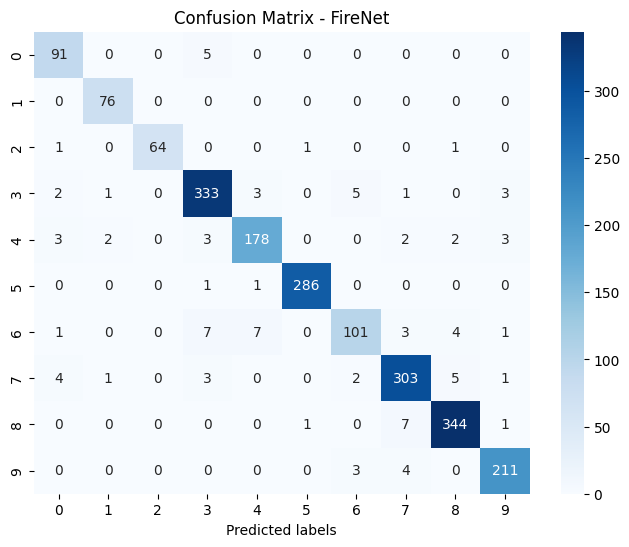

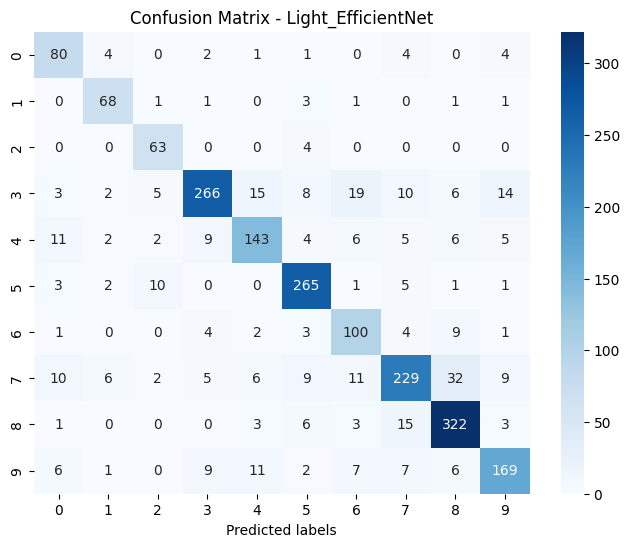

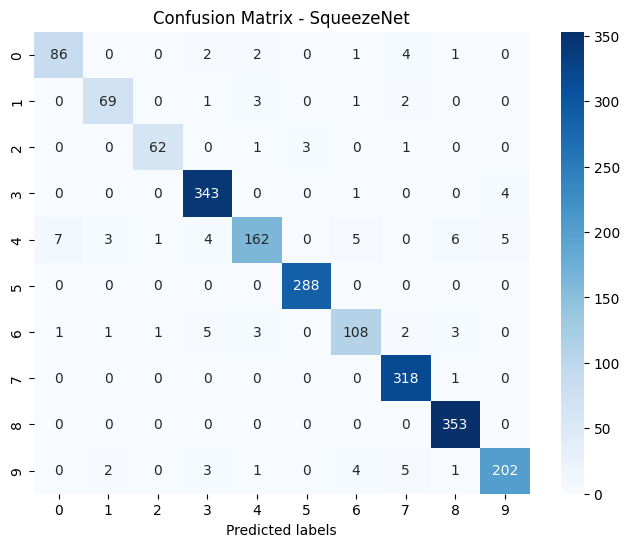

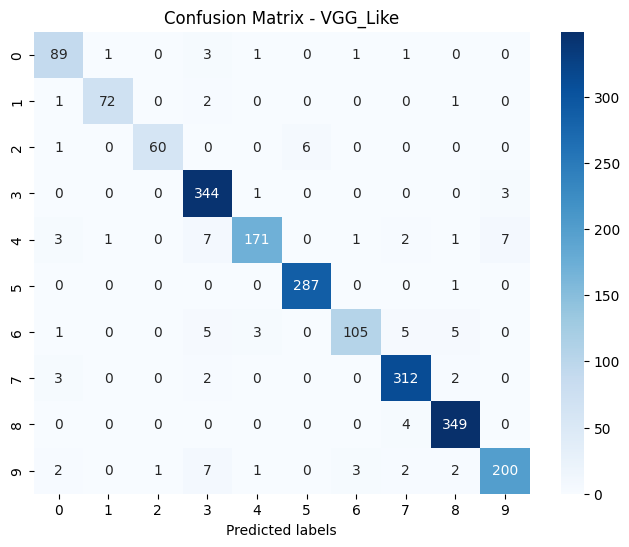

In [ ]:
# Retraining for each model
for model_name, best_params_file in [
    ("FireNet", 'saved_models_classification/FireNet_Tuned/best_params_FireNet.csv'),
    ("Light_EfficientNet", 'saved_models_classification/Light_EfficientNet_Tuned/best_params_Light_EfficientNet.csv'),
    ("SqueezeNet", 'saved_models_classification/SqueezeNet_Tuned/best_params_SqueezeNet.csv'),
    ("VGG_Like", 'saved_models_classification/VGG_Like_Tuned/best_params_VGG_Like.csv')
]:
    # Ensure directory for saving results exists
    output_dir = create_results_dir(model_name)
    
  
    # Call retrain_model with the correct parameters (pass the file path)
    retrain_model(model_name, best_params_file, train_generator, val_generator, output_dir)
    
    print(f"{model_name} retraining completed and results saved.\n")


### Result

| Model             | Accuracy | F1 Score | Precision | ROC AUC |
|-------------------|----------|----------|-----------|---------|
| **FireNet**       | 0.9544   | 0.9489   | 0.9505    | 0.9966  |
| **VGG_Like**      | 0.9553   | 0.9453   | 0.9553    | 0.9960  |
| **SqueezeNet**    | 0.9563   | 0.9407   | 0.9476    | 0.9956  |
| **Light_EfficientNet** | 0.8189 | 0.8099  | 0.7966    | 0.9780  |


# 18. Predict on Test Dataset

In [160]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import os

# === Paths ===
test_image_dir = "test_images"
submission_path = "prediction_submission.csv"
firenet_model_path = "saved_models_classification/FireNet_Retrained/FireNet_final_model.h5"
output_submission_path = "prediction_submission_firenet.csv"

# === Load submission CSV ===
submission_df = pd.read_csv(submission_path)

# === Add full image paths for test images ===
submission_df['filepath'] = submission_df['image_id'].apply(lambda x: os.path.join(test_image_dir, x))

# === Prepare test generator (rescale only) ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=submission_df,
    x_col='filepath',
    y_col=None,  # no labels in test
    target_size=CONFIG['INPUT_SIZE'],
    class_mode=None,
    shuffle=False,
    batch_size=CONFIG['BATCH_SIZE']
)

# === Load trained FireNet model ===
firenet_model = load_model(firenet_model_path)

# === Predict probabilities and decode labels ===
pred_proba = firenet_model.predict(test_generator, verbose=1)
pred_indices = np.argmax(pred_proba, axis=1)

# === Use original class indices to decode
class_indices = train_generator.class_indices
inv_class_indices = {v: k for k, v in class_indices.items()}
pred_labels = [inv_class_indices[idx] for idx in pred_indices]

# === Update submission file
submission_df['label'] = pred_labels

# === Save updated predictions
submission_df[['image_id', 'label', 'variety', 'age']].to_csv(output_submission_path, index=False)
print(f"✅ Predictions saved to: {output_submission_path}")


Found 3469 validated image filenames.
109/109 [==============================] - 6s 54ms/step
✅ Predictions saved to: prediction_submission_firenet.csv
